In [ ]:
# ==========================
# Librerías
# ==========================

import os
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


plt.rcParams["figure.figsize"]=(10,5)
pd.set_option("display.max_columns",None)

In [58]:
# ==========================
# Cargar las bases de datos
# ==========================

data_train=r"Data\train"
data_val=r"Data\val"
data_test=r"Data\test"

paths={"train":data_train,"val":data_val,"test":data_test}

for name,path in paths.items():
  print(f"\n{name.upper()}")
  print(os.listdir(path))


TRAIN
['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']

VAL
['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']

TEST
['Covid-19', 'Emphysema', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral', 'Tuberculosis']


In [59]:
# ==========================
# Crear dataframe
# ==========================

records=[]

datasets={
    "train":data_train,
    "val":data_val,
    "test":data_test
}

valid_ext=(".png",".jpg",".jpeg")

for split,path in datasets.items():
    classes=sorted(os.listdir(path))

    for disease in classes:
        class_path=os.path.join(path,disease)

        if not os.path.isdir(class_path):
            continue

        images=[img for img in os.listdir(class_path)
                if img.lower().endswith(valid_ext)]

        print(f"{split} | {disease}: {len(images)} imágenes")

        for image_name in images:
            records.append({
                "split":split,
                "disease":disease,
                "image_path":os.path.join(class_path,image_name)
            })

df=pd.DataFrame(records)

print("\nDimensiones:")
print(df.shape)

print("\nClases encontradas:")
print(df["disease"].unique())

train | Covid-19: 2417 imágenes
train | Emphysema: 2050 imágenes
train | Normal: 2671 imágenes
train | Pneumonia-Bacterial: 2400 imágenes
train | Pneumonia-Viral: 2413 imágenes
train | Tuberculosis: 2600 imágenes
val | Covid-19: 300 imágenes
val | Emphysema: 250 imágenes
val | Normal: 300 imágenes
val | Pneumonia-Bacterial: 300 imágenes
val | Pneumonia-Viral: 300 imágenes
val | Tuberculosis: 298 imágenes
test | Covid-19: 300 imágenes
test | Emphysema: 250 imágenes
test | Normal: 300 imágenes
test | Pneumonia-Bacterial: 300 imágenes
test | Pneumonia-Viral: 300 imágenes
test | Tuberculosis: 287 imágenes

Dimensiones:
(18036, 3)

Clases encontradas:
['Covid-19' 'Emphysema' 'Normal' 'Pneumonia-Bacterial' 'Pneumonia-Viral'
 'Tuberculosis']


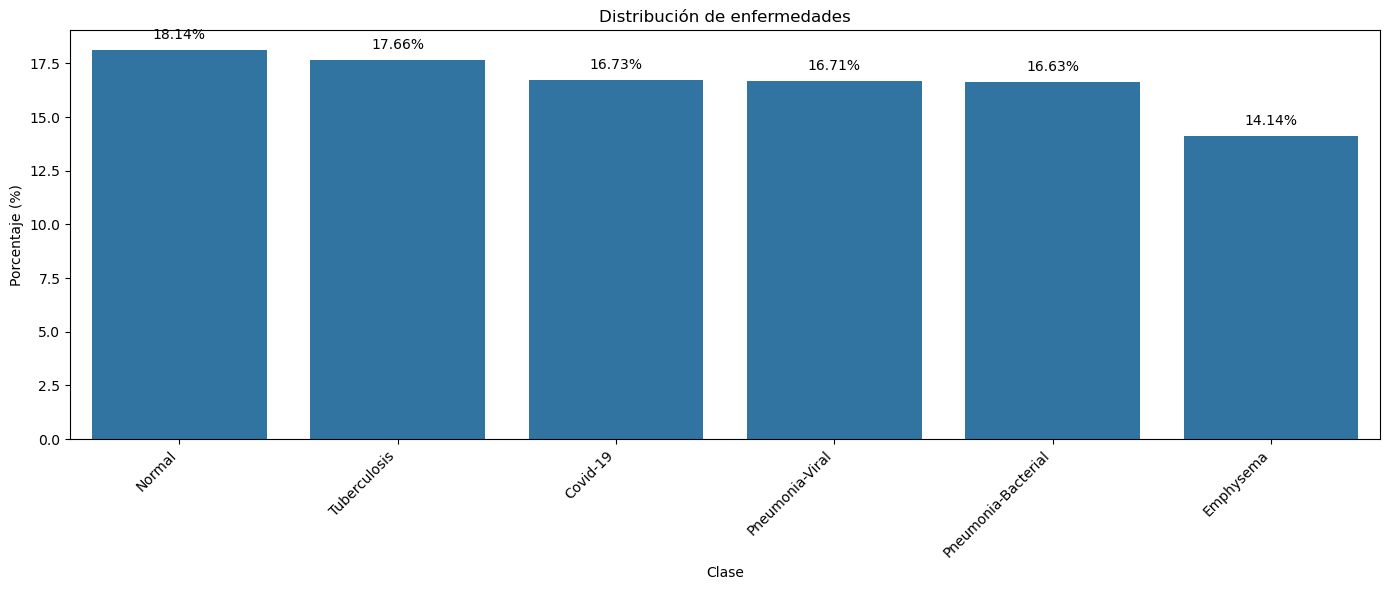

In [60]:
# ==========================
# Distribución de clases (%)
# ==========================

class_percent=df["disease"].value_counts(normalize=True)*100

plt.figure(figsize=(14,6))

ax=sns.barplot(
    x=class_percent.index,
    y=class_percent.values
)

for i,v in enumerate(class_percent.values):
    ax.text(
        i,
        v+0.5,
        f"{v:.2f}%",
        ha="center"
    )

plt.xticks(rotation=45,ha="right")

plt.title("Distribución de enfermedades")
plt.xlabel("Clase")
plt.ylabel("Porcentaje (%)")

plt.tight_layout()
plt.show()

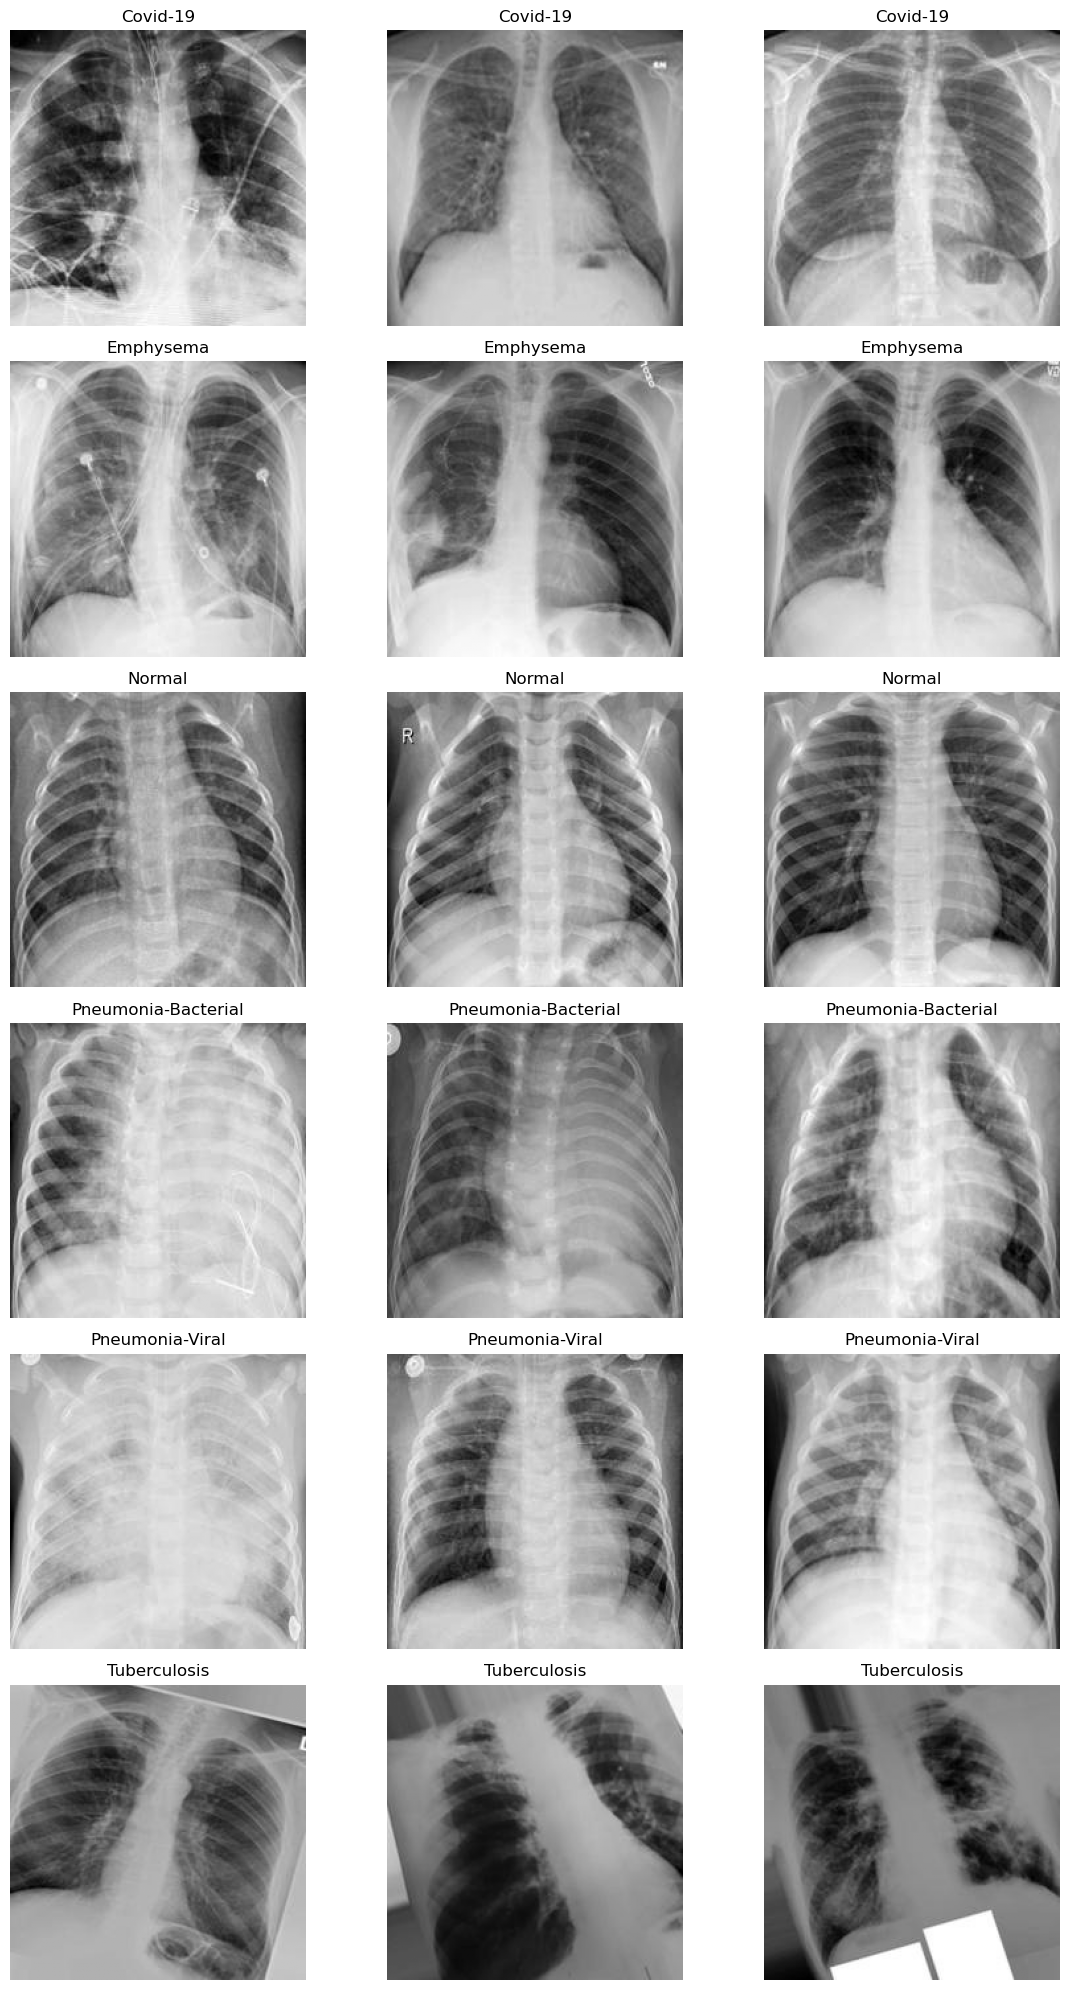

In [61]:
# ==========================
# Revisar imágenes
# ==========================

from PIL import Image

classes=df["disease"].unique()

fig,ax=plt.subplots(len(classes),3,figsize=(12,20))

for i,disease in enumerate(classes):
  samples=df[df["disease"]==disease].sample(3)
  for j,(_,row) in enumerate(samples.iterrows()):
    img=Image.open(row["image_path"])
    ax[i,j].imshow(img,cmap="gray")
    ax[i,j].axis("off")
    ax[i,j].set_title(disease)

plt.tight_layout()
plt.show()

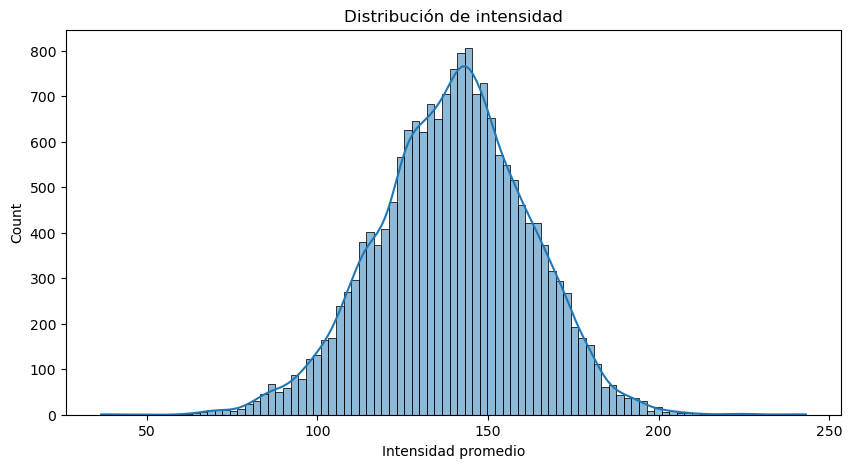

In [ ]:
# ==========================
# Intensidad promedio
# ==========================

import cv2

mean_pixels=[]

for path in df["image_path"]:

    img=cv2.imread(path,0)
    mean_pixels.append(np.mean(img))

df["mean_pixel"]=mean_pixels

plt.figure(figsize=(10,5))

sns.histplot(
    df["mean_pixel"],
    kde=True
)

plt.xlabel("Intensidad promedio")
plt.title("Distribución de intensidad")
plt.show()

La intensidad promedio de los pixeles presenta un comportamiento que sigue una distribución normal, esto puede indicar que la mayoria de las imagenes tienen un nivel de brillo y cntraste homogeneo. Por lo tanto, se puede descartar la idea de que existen muchas imagenes oscuras o sobreexpuestas reduciendo el riesgo a sesgos generados por diferencias en la iluminación.

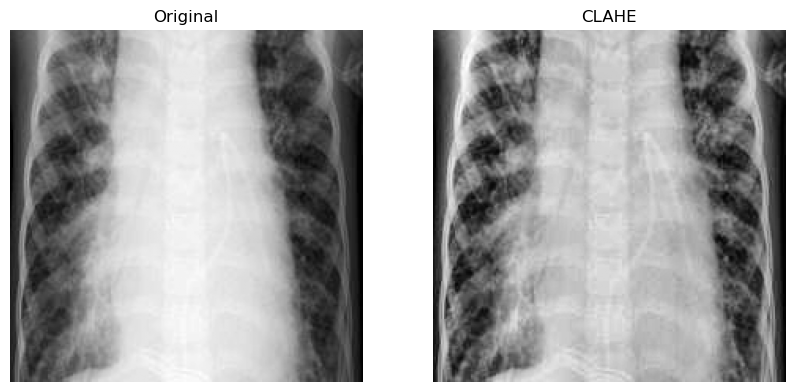

In [63]:
# ==========================
# Mejorar contraste
# ==========================

import cv2

sample=df.sample(1)["image_path"].iloc[0]

img=cv2.imread(sample,0)

clahe=cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)

enhanced=clahe.apply(img)

fig,ax=plt.subplots(1,2,figsize=(10,5))

ax[0].imshow(img,cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(enhanced,cmap="gray")
ax[1].set_title("CLAHE")
ax[1].axis("off")

plt.show()

La aplicación de CLAHE permitió mejorar el contraste local de las imágenes radiográficas, resaltando estructuras anatómicas relevantes como bordes pulmonares y regiones internas del tórax. Esta técnica facilita la identificación de patrones asociados a enfermedades respiratorias y puede ayudar al modelo a diferenciar características discriminantes entre clases.

In [64]:
# ==========================
# Procesar imágenes
# ==========================

def preprocess_images(data,size=(64,64),use_clahe=False):

    X=[]
    y=[]

    for _,row in data.iterrows():

        img=cv2.imread(row["image_path"],0)

        img=cv2.resize(img,size)

        if use_clahe:

            clahe=cv2.createCLAHE(
                clipLimit=2.0,
                tileGridSize=(8,8)
            )

            img=clahe.apply(img)

        img=img/255.0
        img=img.flatten()

        X.append(img)
        y.append(row["disease"])

    return np.array(X),np.array(y)

In [65]:
# ==========================
# Separar datos
# ==========================

df_all=df.copy()

train_df,temp_df=train_test_split(
    df_all,
    test_size=0.30,
    stratify=df_all["disease"],
    random_state=42
)

val_df,test_df=train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["disease"],
    random_state=42
)

print("Train:",train_df.shape)
print("Validation:",val_df.shape)
print("Test:",test_df.shape)

Train: (12625, 4)
Validation: (2705, 4)
Test: (2706, 4)


Se realizó una división estratificada de los datos manteniendo la proporción de cada enfermedad en los tres conjuntos. Se asignó 70% para entrenamiento con el objetivo de disponer de suficiente información para el aprendizaje del modelo, 15% para validación para ajuste de hiperparámetros y detección de sobreajuste, y 15% para prueba para obtener una estimación imparcial del desempeño final.

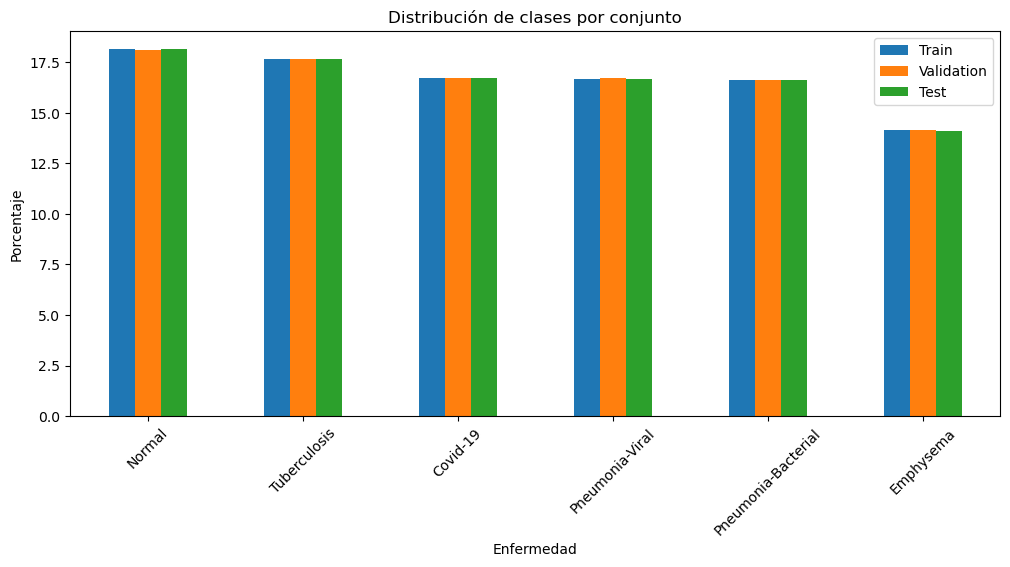

In [66]:
# ==========================
# Distribución por conjuntos
# ==========================

dist=pd.concat([
    train_df["disease"].value_counts(normalize=True),
    val_df["disease"].value_counts(normalize=True),
    test_df["disease"].value_counts(normalize=True)
],axis=1)

dist.columns=["Train","Validation","Test"]

dist=(dist*100).round(2)

dist

# ==========================
# Balance de clases
# ==========================

dist.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Porcentaje")
plt.xlabel("Enfermedad")
plt.title(
    "Distribución de clases por conjunto"
)

plt.xticks(rotation=45)

plt.show()

La división estratificada permitió conservar proporciones similares de cada enfermedad en los conjuntos de entrenamiento, validación y prueba, reduciendo el riesgo de sesgos durante el aprendizaje y evaluación.

In [70]:
# ==========================
# Convertir imágenes
# ==========================

X_train,y_train=preprocess_images(train_df)
X_val,y_val=preprocess_images(val_df)
X_test,y_test=preprocess_images(test_df)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(12625, 4096)
(2705, 4096)
(2706, 4096)


In [71]:
# ==========================
# Transformar clases
# ==========================

encoder=LabelEncoder()

y_train=encoder.fit_transform(y_train)
y_val=encoder.transform(y_val)
y_test=encoder.transform(y_test)

num_classes=len(encoder.classes_)

y_train=to_categorical(y_train,num_classes)
y_val=to_categorical(y_val,num_classes)
y_test=to_categorical(y_test,num_classes)

print(encoder.classes_)

['Covid-19' 'Emphysema' 'Normal' 'Pneumonia-Bacterial' 'Pneumonia-Viral'
 'Tuberculosis']


In [76]:
# ==========================
# Función para construir MLP
# ==========================

def create_mlp(input_dim,layers,dropout_rate,learning_rate):

    model=Sequential()

    model.add(
        Dense(
            layers[0],
            activation="relu",
            input_dim=input_dim
        )
    )

    model.add(Dropout(dropout_rate))

    for neurons in layers[1:]:

        model.add(
            Dense(
                neurons,
                activation="relu"
            )
        )

        model.add(
            Dropout(dropout_rate)
        )

    model.add(
        Dense(
            num_classes,
            activation="softmax"
        )
    )

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

Se seleccionó una arquitectura inicial con dos capas ocultas para capturar relaciones no lineales entre las características extraídas de las imágenes sin incrementar excesivamente la complejidad del modelo.

La tasa de aprendizaje o learning rate se puede aplicar los gieuites valore dependiendo del modelo:

| Learning rate |                  Comportamiento |
| ------------- | ------------------------------: |
| 0.1           |       Muy grande, puede oscilar |
| 0.01          | Rápido pero puede ser inestable |
| 0.001         |           Valor común y estable |
| 0.0001        |          Más lento pero estable |
| 0.00001       |                       Muy lento |

En lo que respecta al Dropout o regularización se tiene los siguientes posibles valores a utilizar:

| Dropout |            Interpretación | Posible efecto                                                 |
| ------- | ------------------------: | -------------------------------------------------------------- |
| 0.0     |        Sin regularización | Mayor riesgo de overfitting                                    |
| 0.1     |   Regularización muy baja | Pequeña reducción del sobreajuste                              |
| 0.2     |       Regularización baja | Mantiene capacidad de aprendizaje y reduce algo de sobreajuste |
| 0.3     |   Regularización moderada | Valor muy utilizado en MLP                                     |
| 0.5     |       Regularización alta | Reduce sobreajuste, pero puede perder información útil         |
| >0.5    | Regularización muy fuerte | Riesgo de underfitting                                         |

El objetivo es evitar que el modelo dependa excesivamente de ciertas conexiones y mejorar la capacidad de generalización.

In [77]:
# ==========================
# Espacio de hiperparámetros
# ==========================

num_layers=[2]

neurons=[
    [50,25],
    [100,50]
]

dropouts=[0.2,0.3,0.5]

learning_rates=[0.01,0.001,0.0001]

batch_sizes=[16,32]

# ==========================
# Generar combinaciones
# ==========================

from itertools import product

params=[]

for layer,n,d,lr,b in product(
    num_layers,
    neurons,
    dropouts,
    learning_rates,
    batch_sizes
):

    if len(n)==layer:

        params.append({
            "layers":n,
            "dropout":d,
            "lr":lr,
            "batch_size":b
        })

print("Número de combinaciones:")
print(len(params))
print(params)

Número de combinaciones:
36
[{'layers': [50, 25], 'dropout': 0.2, 'lr': 0.01, 'batch_size': 16}, {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.01, 'batch_size': 32}, {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.001, 'batch_size': 16}, {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.001, 'batch_size': 32}, {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 16}, {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0001, 'batch_size': 32}, {'layers': [50, 25], 'dropout': 0.3, 'lr': 0.01, 'batch_size': 16}, {'layers': [50, 25], 'dropout': 0.3, 'lr': 0.01, 'batch_size': 32}, {'layers': [50, 25], 'dropout': 0.3, 'lr': 0.001, 'batch_size': 16}, {'layers': [50, 25], 'dropout': 0.3, 'lr': 0.001, 'batch_size': 32}, {'layers': [50, 25], 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 16}, {'layers': [50, 25], 'dropout': 0.3, 'lr': 0.0001, 'batch_size': 32}, {'layers': [50, 25], 'dropout': 0.5, 'lr': 0.01, 'batch_size': 16}, {'layers': [50, 25], 'dropout': 0.5, 'lr': 0.01, 'batch_size': 32}, {'layer

In [78]:
# ==========================
# Validación cruzada
# ==========================

results=[]
fold_results=[]

y_train_labels=np.argmax(y_train,axis=1)

cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

early_stop=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

for p in params:

    scores=[]

    for fold,(train_idx,val_idx) in enumerate(
        cv.split(X_train,y_train_labels)
    ):

        X_tr=X_train[train_idx]
        X_cv=X_train[val_idx]

        y_tr=y_train[train_idx]
        y_cv=y_train[val_idx]

        model=create_mlp(
            input_dim=X_train.shape[1],
            layers=p["layers"],
            dropout_rate=p["dropout"],
            learning_rate=p["lr"]
        )

        model.fit(
            X_tr,
            y_tr,
            validation_data=(X_cv,y_cv),
            epochs=30,
            batch_size=p["batch_size"],
            callbacks=[early_stop],
            verbose=0
        )

        _,acc=model.evaluate(
            X_cv,
            y_cv,
            verbose=0
        )

        scores.append(acc)

        fold_results.append({
            "config":str(p),
            "fold":fold+1,
            "accuracy":acc
        })

    results.append({
        "config":str(p),
        "mean_accuracy":np.mean(scores),
        "std_accuracy":np.std(scores)
    })

results=pd.DataFrame(results)

results=results.sort_values(
    "mean_accuracy",
    ascending=False
)

results.head()

c:\Users\ASUS VIVOBOOK PRO\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\ASUS VIVOBOOK PRO\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\ASUS VIVOBOOK PRO\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

,config,mean_accuracy,std_accuracy
22,"{'layers': [100, 50], 'dropout': 0.2, 'lr': 0....",0.651406,0.068723
23,"{'layers': [100, 50], 'dropout': 0.2, 'lr': 0....",0.591842,0.044027
5,"{'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0...",0.579327,0.018544
28,"{'layers': [100, 50], 'dropout': 0.3, 'lr': 0....",0.572198,0.010979
29,"{'layers': [100, 50], 'dropout': 0.3, 'lr': 0....",0.567525,0.044342


                                              config  fold  accuracy
0  {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0...     1  0.176634
1  {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0...     2  0.167525
2  {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0...     3  0.167129
3  {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0...     4  0.181386
4  {'layers': [50, 25], 'dropout': 0.2, 'lr': 0.0...     5  0.181386


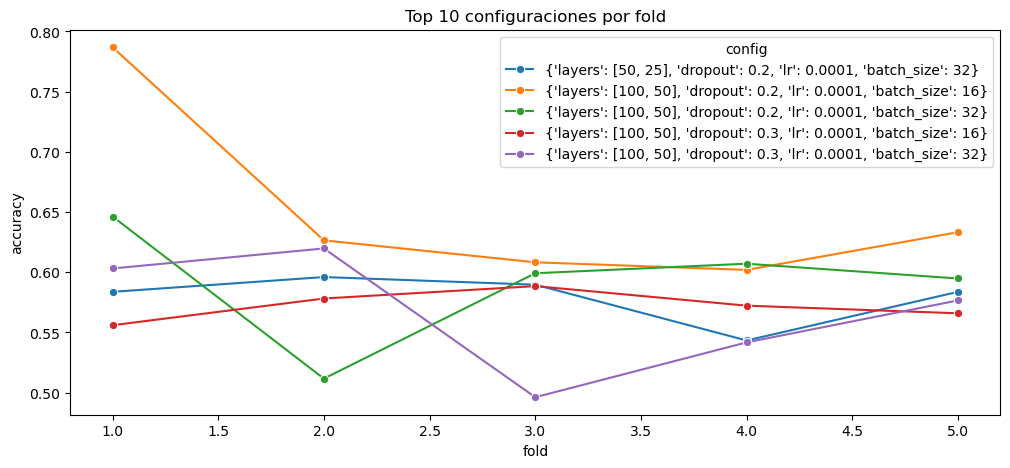

In [82]:
# ==========================
# Convertir a DataFrame
# ==========================

fold_results=pd.DataFrame(fold_results)

print(fold_results.head())

# ==========================
# Top 10 configuraciones
# ==========================

top_configs=results.head(5)["config"]

fold_top=fold_results[
    fold_results["config"].isin(top_configs)
]

plt.figure(figsize=(12,5))

sns.lineplot(
    data=fold_top,
    x="fold",
    y="accuracy",
    hue="config",
    marker="o"
)

plt.title(
    "Top 10 configuraciones por fold"
)

plt.show()

In [84]:
# ==========================
# Top 5 mejores modelos
# ==========================

summary=results.copy()

summary["layers"]=summary["config"].apply(
    lambda x:eval(x)["layers"]
)

summary["dropout"]=summary["config"].apply(
    lambda x:eval(x)["dropout"]
)

summary["learning_rate"]=summary["config"].apply(
    lambda x:eval(x)["lr"]
)

summary["batch_size"]=summary["config"].apply(
    lambda x:eval(x)["batch_size"]
)

summary["num_layers"]=summary["layers"].apply(
    lambda x:len(x)
)

summary["neurons"]=summary["layers"].apply(
    lambda x:",".join(map(str,x))
)

summary=summary[[
    "num_layers",
    "neurons",
    "dropout",
    "learning_rate",
    "batch_size",
    "mean_accuracy",
    "std_accuracy"
]]

summary["score"]=(
    summary["mean_accuracy"]-
    summary["std_accuracy"]
)

top5=summary.sort_values(
    "score",
    ascending=False
).head(5)

top5=top5.reset_index(drop=True)

top5

,num_layers,neurons,dropout,learning_rate,batch_size,mean_accuracy,std_accuracy,score
0,2,"100,50",0.2,0.0001,16,0.651406,0.068723,0.582683
1,2,"100,50",0.3,0.0001,16,0.572198,0.010979,0.561219
2,2,"50,25",0.2,0.0001,32,0.579327,0.018544,0.560782
3,2,"100,50",0.2,0.0001,32,0.591842,0.044027,0.547814
4,2,"100,50",0.3,0.0001,32,0.567525,0.044342,0.523183


In [86]:
# ==========================
# Modelo inicial
# ==========================

best_config={
    "layers":[100,50],
    "dropout":0.2,
    "lr":0.0001,
    "batch_size":16
}

model=create_mlp(
    input_dim=X_train.shape[1],
    layers=best_config["layers"],
    dropout_rate=best_config["dropout"],
    learning_rate=best_config["lr"]
)

history=model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    epochs=30,
    callbacks=[early_stop],
    batch_size=best_config["batch_size"]
)

c:\Users\ASUS VIVOBOOK PRO\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
790/790 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4762 - loss: 1.2529 - val_accuracy: 0.6322 - val_loss: 0.8937
Epoch 2/30
790/790 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5892 - loss: 0.9598 - val_accuracy: 0.6943 - val_loss: 0.7894
Epoch 3/30
790/790 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6263 - loss: 0.8776 - val_accuracy: 0.6847 - val_loss: 0.7513


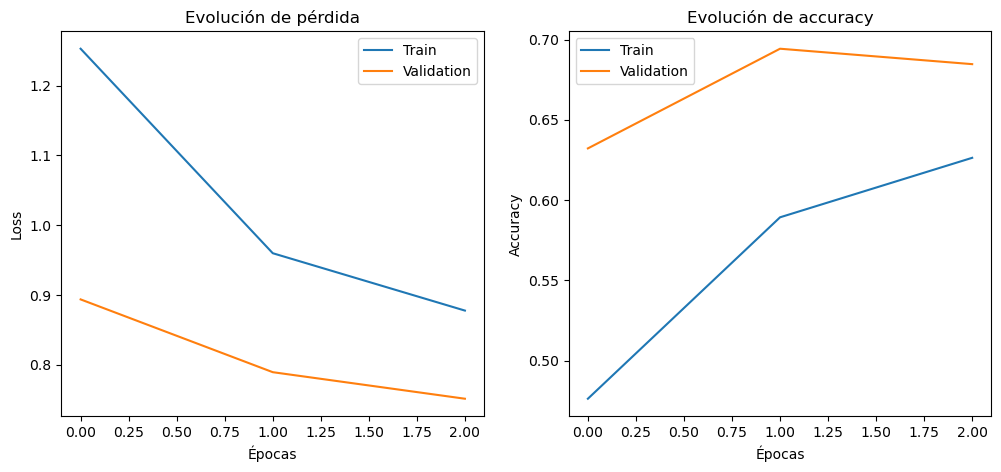

In [87]:
# ==========================
# Curvas de entrenamiento
# ==========================

fig,ax=plt.subplots(1,2,figsize=(12,5))

ax[0].plot(history.history["loss"])
ax[0].plot(history.history["val_loss"])
ax[0].set_title("Evolución de pérdida")

ax[0].set_xlabel("Épocas")
ax[0].set_ylabel("Loss")
ax[0].legend(["Train","Validation"])

ax[1].plot(history.history["accuracy"])
ax[1].plot(history.history["val_accuracy"])
ax[1].set_title("Evolución de accuracy")

ax[1].set_xlabel("Épocas")
ax[1].set_ylabel("Accuracy")
ax[1].legend(["Train","Validation"])

plt.show()

85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy:0.6275
Recall:0.6275
F1:0.6170


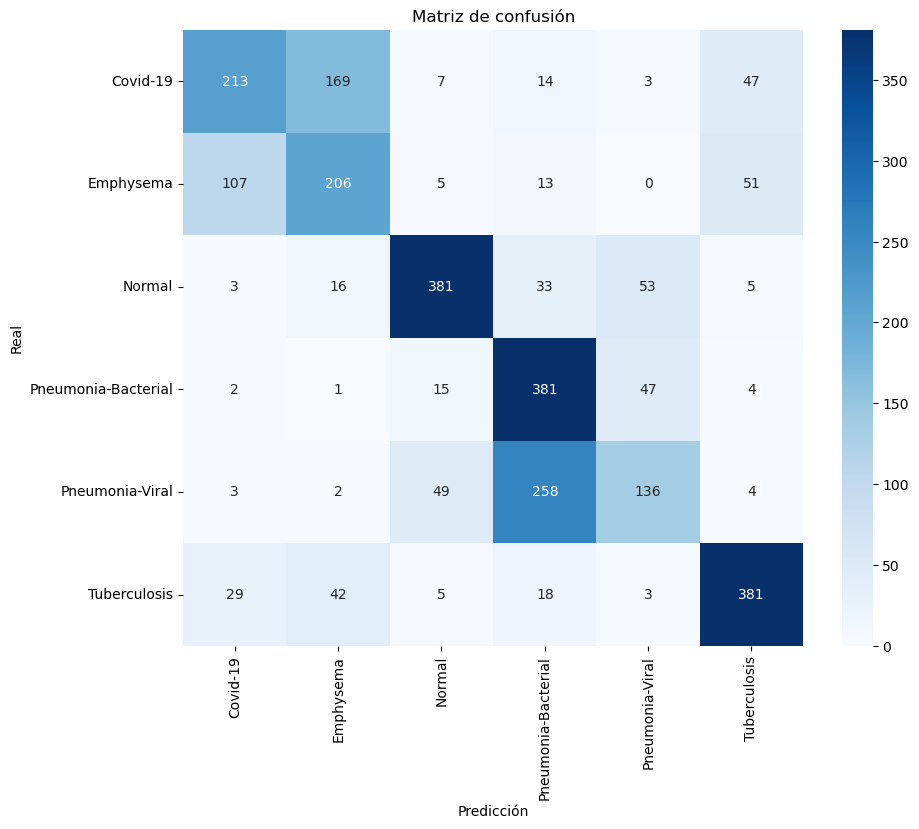

In [ ]:
# ==========================
# Predicciones
# ==========================

y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred,axis=1)
y_real=np.argmax(y_test,axis=1)

# ==========================
# Métricas
# ==========================

from sklearn.metrics import(
    accuracy_score,
    recall_score,
    f1_score
)

accuracy=accuracy_score(y_real,y_pred)
recall=recall_score(y_real,y_pred,average="weighted")
f1=f1_score(y_real,y_pred,average="weighted")

print(f"Accuracy:{accuracy:.4f}")
print(f"Recall:{recall:.4f}")
print(f"F1:{f1:.4f}")

# ==========================
# Matriz de confusión
# ==========================

from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_real,y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

In [91]:
# ==========================
# Reporte clasificación
# ==========================

from sklearn.metrics import classification_report

print(
    classification_report(
        y_real,
        y_pred,
        target_names=encoder.classes_
    )
)

                     precision    recall  f1-score   support

           Covid-19       0.60      0.47      0.53       453
          Emphysema       0.47      0.54      0.50       382
             Normal       0.82      0.78      0.80       491
Pneumonia-Bacterial       0.53      0.85      0.65       450
    Pneumonia-Viral       0.56      0.30      0.39       452
       Tuberculosis       0.77      0.80      0.79       478

           accuracy                           0.63      2706
          macro avg       0.63      0.62      0.61      2706
       weighted avg       0.64      0.63      0.62      2706

